<a id="prereq"></a>
## Проєкт 🍕🍽️ Pizza Restaurant Sales

Датасет для проєкту завантажений з сайту KAGGLE за посиланням https://www.kaggle.com/datasets/ankitrajmishra/pizza-place-sales-analysis/data

Проблема:
Піцерія зіткнулася зі зниженням продажів і планує збільшити їх, вивчивши дані про клієнтів та замовлення. Для цього керівництво збирається провести ретельний аналіз даних про замовлення та поведінку споживачів, щоб виявити ключові тенденції та сфери для покращення.

Контекст:
У цьому звіті представлено огляд даних про продажі піци з січня 2015 року по грудень 2015 року. Для виявлення тенденцій та закономірностей у продажах піци було зібрано та проаналізовано дані з піцерій

Про набір даних 📅
Цей набір даних містить 4 таблиці у форматі CSV:
 - Таблиця Orders (Замовлення) містить дату та час здійснення всіх замовлень.
 - Таблиця Order_Details (Деталі замовлення) містить інформацію про різні види піци, подані в кожному замовленні з таблиці Orders, а також їхню кількість.
 - Таблиця Pizzas (Піци) містить розмір і ціну для кожної окремої піци з таблиці Order Details, а також її загальний тип.
 - Таблиця Pizza_Types (Типи піци) містить детальну інформацію про типи піци з таблиці Pizzas, включаючи їхню назву в меню, категорію, до якої вони належать, та список інгредієнтів.

Для аналізу датасету було використано Python та BigQuery

<a id="prereq"></a>
## 1. Імпортуємо всі необхідні бібліотеки




In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from google.cloud import bigquery
from google.oauth2 import service_account
from scipy import stats
import warnings

In [ ]:
%pip install google-cloud-bigquery db-dtypes --quiet

In [ ]:
%pip install google-cloud-bigquery storage pyarrow

<a id="prereq"></a>
## 2. Аналізуємо датасет, попередньо завантажений у BigQuery



In [2]:
warnings.filterwarnings("ignore", category = FutureWarning)
warnings.filterwarnings("ignore", category = UserWarning)

In [3]:
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "pizza-restaurant-sales-57f257f4ebce.json"
credentials = service_account.Credentials.from_service_account_file('pizza-restaurant-sales-57f257f4ebce.json')

In [4]:
client = bigquery.Client()

Розглянемо яких типів маємо дані та перевіримо на наявність NULL 
(Запит формуємо у bigquery)

DECLARE query STRING;

SET query = (
  SELECT STRING_AGG(
    FORMAT("""
      SELECT
        '%s' AS table_name,
        '%s' AS column_name,
        '%s' AS data_type,
        COUNTIF(%s IS NULL) AS null_count,
        COUNT(*) AS total_rows
      FROM `pizza-restaurant-sales.pizza_place_sales_analysis.%s`
    """, table_name, column_name, data_type, column_name, table_name),
    ' UNION ALL '
  )
  FROM `pizza-restaurant-sales.pizza_place_sales_analysis.INFORMATION_SCHEMA.COLUMNS`
);


SET query = FORMAT("""
  SELECT *,
    ROUND(SAFE_DIVIDE(null_count, total_rows) * 100, 2) AS null_percentage
  FROM (%s)
  ORDER BY table_name, null_count DESC
""", query);


EXECUTE IMMEDIATE query;



In [5]:
# Результат перевірки з BigQuery
!BigQuery.jpg

1. Розглянемо загальну інформацію по датасету: період аналізу даних, загальна кількість замовлень, 
загальна кількість реалізованої продукції, загальний виторг, середній чек

In [6]:
# 1.
query = f"""
SELECT 
    MIN(o.date) AS data_start_date,
    MAX(o.date) AS data_end_date,
    COUNT(DISTINCT o.order_id) AS total_orders_count,
    SUM(od.quantity) AS total_pizzas_sold,
    ROUND(SUM(od.quantity * p.price), 2) AS total_revenue,
    ROUND(SUM(od.quantity * p.price) / COUNT(DISTINCT o.order_id), 2) AS average_order_value
FROM `pizza-restaurant-sales.pizza_place_sales_analysis.orders` AS o
JOIN `pizza-restaurant-sales.pizza_place_sales_analysis.order_details` AS od
    ON o.order_id = od.order_id
JOIN `pizza-restaurant-sales.pizza_place_sales_analysis.pizzas` AS p
    ON od.pizza_id = p.pizza_id
"""

# 2. 
df_dataset_summary = client.query(query).to_dataframe()

# 3. 
df_dataset_summary.style.format({
    'total_orders_count': '{:,}',
    'total_pizzas_sold': '{:,}',
    'total_revenue': '${:,.2f}',
    'average_order_value': '${:.2f}'
}).hide(axis='index')

data_start_date,data_end_date,total_orders_count,total_pizzas_sold,total_revenue,average_order_value
2015-01-01,2015-12-31,"21,350","49,574","$817,860.05",$38.31


2. Розглянемо асортимент та середню вартість продукції

In [7]:
query = f"""
SELECT 
    pizza_type_id, 
    AVG(price) AS avg_price
FROM `pizza-restaurant-sales.pizza_place_sales_analysis.pizzas`
GROUP BY pizza_type_id
ORDER BY avg_price ASC
"""

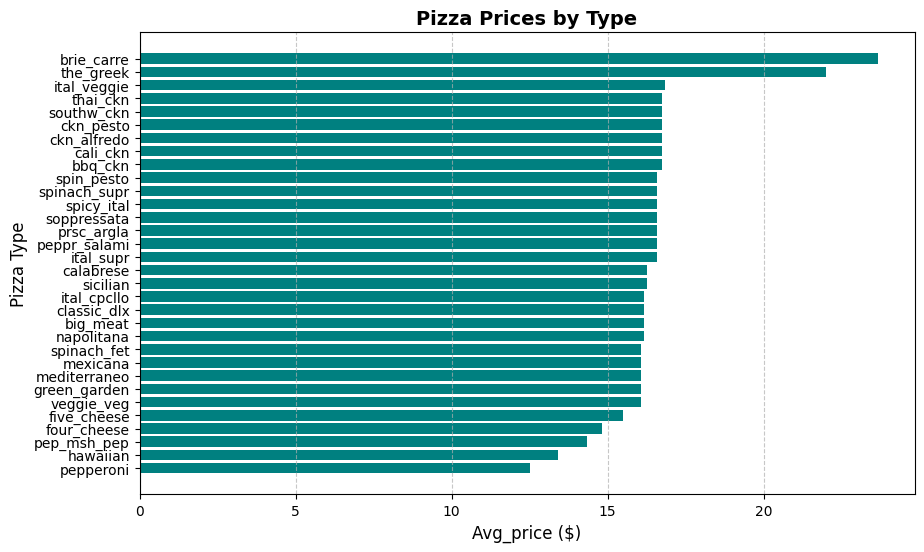

In [8]:
# 1. 
df_Pizza_Prices_by_Type = client.query(query).to_dataframe()

# 2. 
plt.figure(figsize=(10, 6))

# 3. 
plt.barh(df_Pizza_Prices_by_Type['pizza_type_id'], df_Pizza_Prices_by_Type['avg_price'], color='teal')

# 4. 
plt.title('Pizza Prices by Type', fontsize=14, fontweight='bold')
plt.xlabel('Avg_price ($)', fontsize=12)
plt.ylabel('Pizza Type', fontsize=12)

# 5. 
plt.grid(axis='x', linestyle='--', alpha=0.7)

# 6. 
plt.show()

З графіку бачимо, що найдорожчі позиції - це "brie_carre" та "the_greek" з середньою вартістю понад 22 $
А найдешевшими є "hawaiian", "pepperoni" та "pep_msh_pep" з середньою вартістю менше 15 $
Більшість асортименту має середню вартість близько 17 $

3. Проаналізуємо, які піци за розміром найбільш популярні серед клієнтів

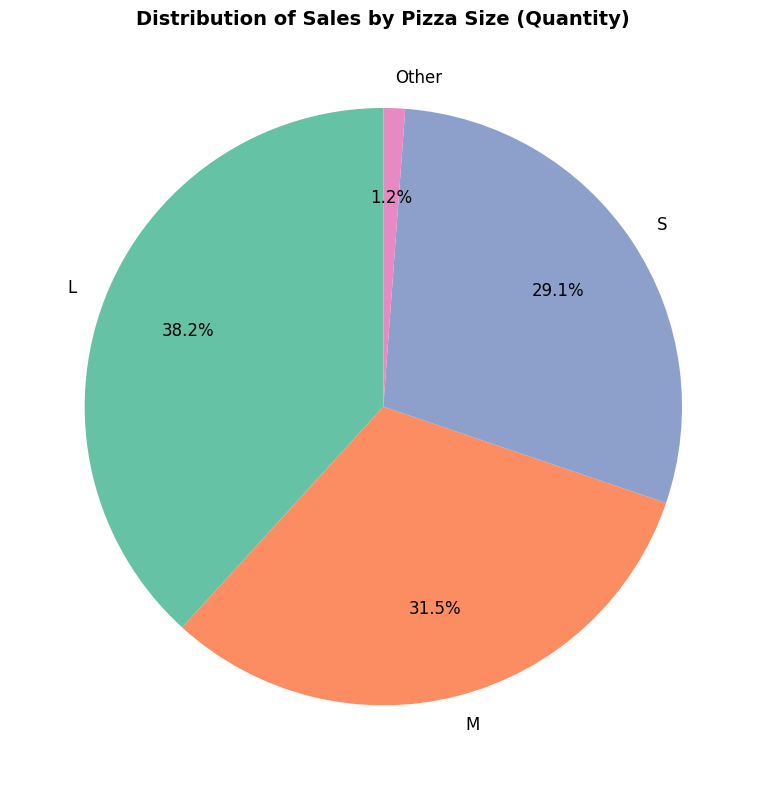

In [9]:
# 1. 
query = f"""
SELECT 
    p.size,
    SUM(od.quantity) AS total_quantity_sold
FROM `pizza-restaurant-sales.pizza_place_sales_analysis.order_details` AS od
JOIN `pizza-restaurant-sales.pizza_place_sales_analysis.pizzas` AS p
    ON od.pizza_id = p.pizza_id
GROUP BY p.size
ORDER BY total_quantity_sold DESC
"""

# 2. 
df_size = client.query(query).to_dataframe()

#  ГРУПУВАННЯ КАТЕГОРІЙ МЕНШЕ 2% 
total_sales = df_size['total_quantity_sold'].sum()
df_size['percentage'] = (df_size['total_quantity_sold'] / total_sales) * 100

main_sectors = df_size[df_size['percentage'] >= 2.0].copy()
small_sectors = df_size[df_size['percentage'] < 2.0]

if not small_sectors.empty:
    other_row = pd.DataFrame([{
        'size': 'Other',
        'total_quantity_sold': small_sectors['total_quantity_sold'].sum(),
        'percentage': small_sectors['percentage'].sum()
    }])
    df_grouped = pd.concat([main_sectors, other_row], ignore_index=True)
else:
    df_grouped = main_sectors


# 3.
plt.figure(figsize=(8, 8))

# 4. 
colors = plt.cm.Set2.colors

# 5. 
plt.pie(
    df_grouped['total_quantity_sold'], 
    labels=df_grouped['size'],   
    autopct='%1.1f%%',          
    startangle=90,              
    colors=colors,             
    pctdistance=0.7,           
    labeldistance=1.1,          
    textprops={'fontsize': 12}  
)

# 6. 
plt.title('Distribution of Sales by Pizza Size (Quantity)', fontsize=14, fontweight='bold')

# 7. 
plt.tight_layout()
plt.show()

З діаграми бачимо, що найбільш популярною є піца розміру L - 38.2% 
Замовлення піци розміру M та S становлять 31,5% та 29,1% відповідно.

4. Розрахуємо загальну виручку за кожним розміром піци.

In [10]:
# 1. 
query = f"""
SELECT 
    p.size AS pizza_size,
    ROUND(AVG(p.price), 2) AS average_pizza_price,
    ROUND(SUM(od.quantity * p.price), 2) AS total_revenue
FROM `pizza-restaurant-sales.pizza_place_sales_analysis.order_details` AS od
JOIN `pizza-restaurant-sales.pizza_place_sales_analysis.pizzas` AS p
    ON od.pizza_id = p.pizza_id
GROUP BY pizza_size
ORDER BY total_revenue DESC
"""

# 2. 
df_sales_by_size = client.query(query).to_dataframe()

# 3. 
df_sales_by_size

,pizza_size,average_pizza_price,total_revenue
0,L,19.80,375318.70
1,M,15.95,249382.25
2,S,12.36,178076.50
3,XL,25.50,14076.00
4,XXL,35.95,1006.60


Найбільшу виручку отримуємо від продажу піци розміру L- 375 318,70 $
Для збільшення продажів піци розміру S можна запропонувати маркетингову активність на кшталт "Kids pizza", тобто додати до меню позицію "Kids pizza", яка буде класичною "Маргаритою" чи "Kids pizza patatine" - класична "Маргарита" зі жменькою картоплі фрі. 
Очікується, що батьки куплять дитині її власну дитячу піцу.

5. Розглянемо виручку по місяцях

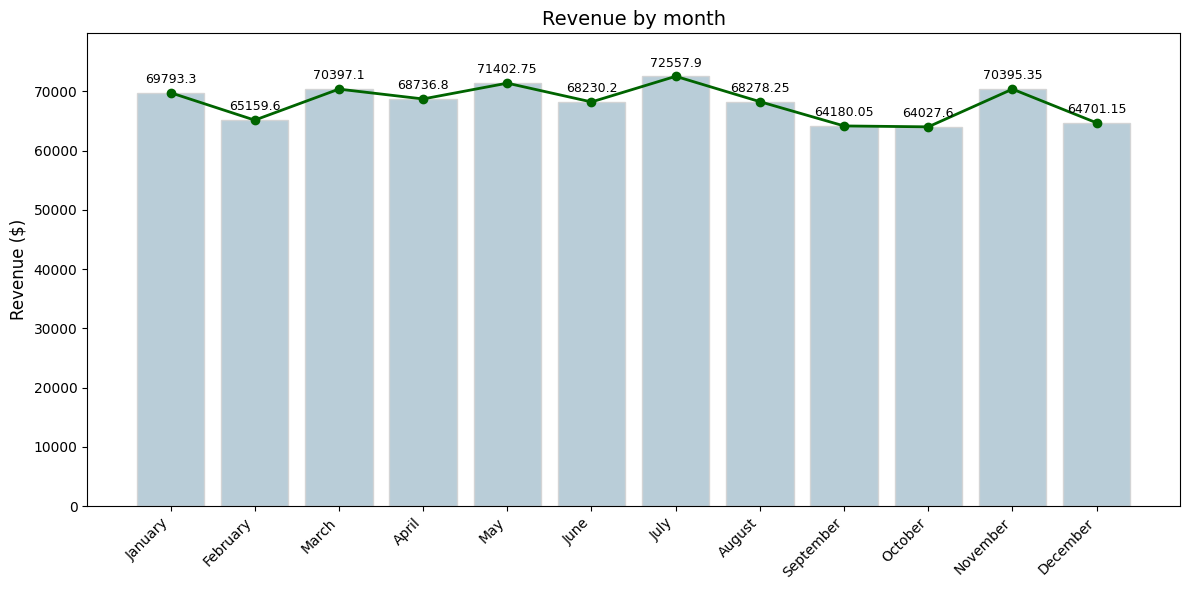

In [11]:
 #1. 
query = f"""
SELECT 
    DATE_TRUNC(o.date, MONTH) AS sales_month,
    FORMAT_DATE('%B', DATE_TRUNC(o.date, MONTH)) AS month_label,
    ROUND(SUM(od.quantity * p.price), 2) AS total_revenue
FROM `pizza-restaurant-sales.pizza_place_sales_analysis.order_details` AS od
JOIN `pizza-restaurant-sales.pizza_place_sales_analysis.pizzas` AS p
    ON od.pizza_id = p.pizza_id
JOIN `pizza-restaurant-sales.pizza_place_sales_analysis.orders` AS o
    ON od.order_id = o.order_id
GROUP BY sales_month, month_label
ORDER BY sales_month ASC
"""

# 2. 
df_revenue_by_month = client.query(query).to_dataframe()

# 3. 
plt.figure(figsize=(12, 6))


# 4. 
plt.bar(
    df_revenue_by_month['month_label'], 
    df_revenue_by_month['total_revenue'], 
    color='#b2c8d4',       
    edgecolor='lightgrey',  
    alpha=0.9
)

# 5. 
plt.plot(
    df_revenue_by_month['month_label'], 
    df_revenue_by_month['total_revenue'], 
    color='darkgreen',           
    marker='o',            
    linewidth=2, 
    markersize=6
)

# 6. 
for i, txt in enumerate(df_revenue_by_month['total_revenue']):
    plt.annotate(
        f'{txt}', 
        (df_revenue_by_month['month_label'].iloc[i], df_revenue_by_month['total_revenue'].iloc[i]),
        textcoords="offset points", 
        xytext=(0, 7),     
        ha='center',        
        fontsize=9
    )


# 7. 
plt.title('Revenue by month', fontsize=14)
plt.ylabel('Revenue ($)', fontsize=12)

# 8. 
plt.ylim(0, max(df_revenue_by_month['total_revenue']) * 1.1)

# 9. 
plt.xticks(rotation=45, ha='right')

# 10. 
plt.tight_layout()

# 11. 
plt.show()

З графіку бачимо, що щомісячна виручка відносно стабільна протягом року 64К -72,5К 
Найбільш дохідним місяцем є липень, що може бути пов'язано з періодом відпусток та частішим харчуванням поза домом 

6. Розглянемо частоту замовлень в розрізі годин дня

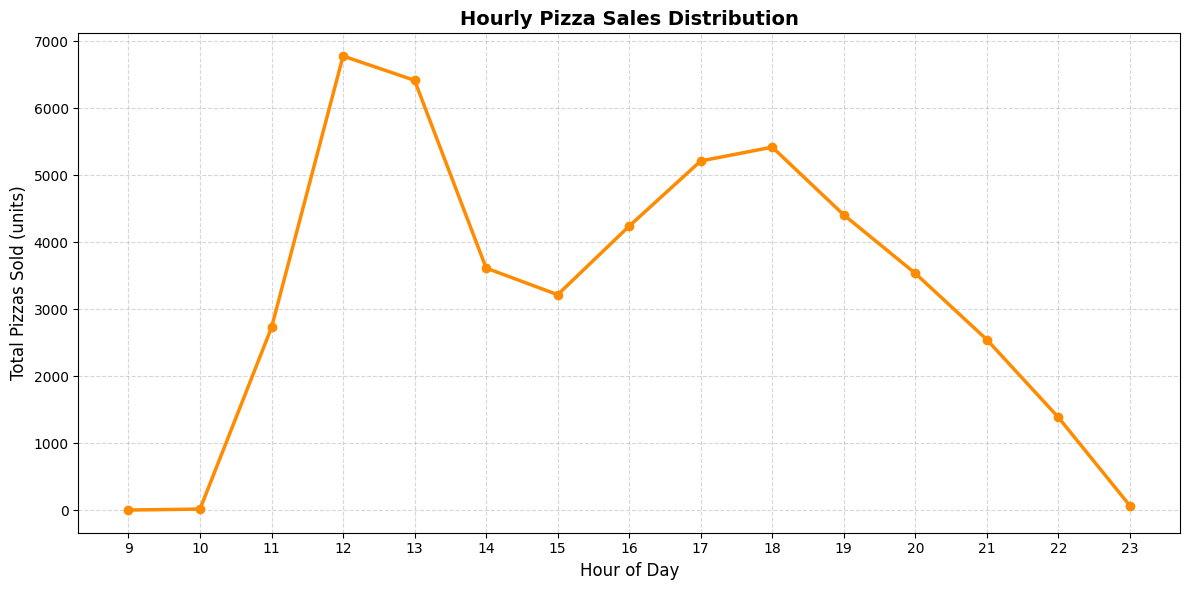

In [12]:
# 1. 
query = f"""
SELECT 
    EXTRACT(HOUR FROM o.time) AS order_hour,
    COUNT(DISTINCT o.order_id) AS total_orders,
    SUM(od.quantity) AS total_pizzas_sold
FROM `pizza-restaurant-sales.pizza_place_sales_analysis.orders` AS o
JOIN `pizza-restaurant-sales.pizza_place_sales_analysis.order_details` AS od
    ON o.order_id = od.order_id
GROUP BY order_hour
ORDER BY order_hour ASC
"""

# 2.
df_orders_by_hour = client.query(query).to_dataframe()

# 3. 
plt.figure(figsize=(12, 6))

# 4. 
plt.plot(
    df_orders_by_hour['order_hour'], 
    df_orders_by_hour['total_pizzas_sold'], 
    color='darkorange', 
    marker='o', 
    linewidth=2.5, 
    markersize=6
)

# 5. 
plt.title('Hourly Pizza Sales Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Total Pizzas Sold (units)', fontsize=12)

# 6. 
plt.xticks(df_orders_by_hour['order_hour'])

# 7. 
plt.grid(True, linestyle='--', alpha=0.5)

# 8. 
plt.tight_layout()

# 9. 
plt.show()

З графіку замовлень по годинах бачимо, що попит має двопіковий характер, тобто обідній час (12:00-13:00)
та вечірній (17:00 -18:00).
Для збільшення кількості замовлень в позапіковий час можна ввести маркетингову активність - "Шматочок піци + кава", як швидкий сніданок або перекус з собою. "Смачні години" - знижка на замовлення з 14:00 до 16:00

7. Проаналізуємо виторг по днях тижня.

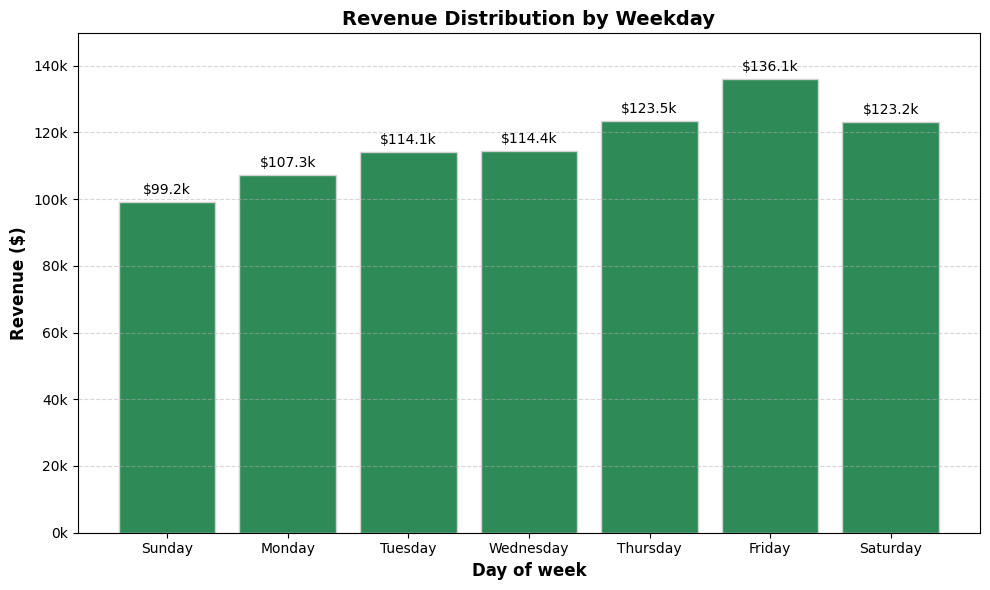

In [13]:
# 1. 
query = f"""
SELECT 
    EXTRACT(DAYOFWEEK FROM o.date) AS weekday_num,
    FORMAT_DATE('%A', o.date) AS weekday_name,
    ROUND(SUM(od.quantity * p.price), 2) AS total_revenue
FROM `pizza-restaurant-sales.pizza_place_sales_analysis.orders` AS o
JOIN `pizza-restaurant-sales.pizza_place_sales_analysis.order_details` AS od
    ON o.order_id = od.order_id
JOIN `pizza-restaurant-sales.pizza_place_sales_analysis.pizzas` AS p
    ON od.pizza_id = p.pizza_id
GROUP BY weekday_num, weekday_name
ORDER BY weekday_num ASC
"""

# 2. 
df_revenue_by_weekday = client.query(query).to_dataframe()

# 3. 
plt.figure(figsize=(10, 6))

# 4. 
plt.bar(
    df_revenue_by_weekday['weekday_name'], 
    df_revenue_by_weekday['total_revenue'], 
    color='seagreen',
    edgecolor='lightgrey'
)


for i, val in enumerate(df_revenue_by_weekday['total_revenue']):
   
    label_text = f"${val * 1e-3:.1f}k"
    
    plt.text(
        x=i, 
        y=val + max(df_revenue_by_weekday['total_revenue']) * 0.01,  
        s=label_text, 
        ha='center',          
        va='bottom', 
        fontsize=10, 
        fontweight='normal',  
        color='black'         
    )

def k_formatter(x, pos):
    return f'{x*1e-3:,.0f}k'

plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(k_formatter))


plt.ylim(0, max(df_revenue_by_weekday['total_revenue']) * 1.1)


# 5. 
plt.title('Revenue Distribution by Weekday', fontsize=14, fontweight='bold')
plt.xlabel('Day of week', fontsize=12, fontweight='bold')
plt.ylabel('Revenue ($)', fontsize=12, fontweight='bold')


plt.xticks(fontweight='normal', color='black')
plt.yticks(fontweight='normal', color='black')

# 6. 
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 7. 
plt.tight_layout()

# 8. 
plt.show()

З графіку бачимо зростання виторгу з понеділка по п'ятницю.
П'ятниця є піковою за соціальними та психологічними факторами - кінець робочого тижня/початок вихідних, зустрічі з друзями.
Для зростання продажів у суботу-неділю можна запропонувати маркетингові акції "Сімейні вихідні" - до двох піц розміру L, третя піца розміру S
у подарунок. "Недільна вечеря без турбот" - при замовленні від трьох піц діє знижка або йде накопичення бонусів.

8.Розглянемо дохід по кожній з категорій піци

In [14]:
# 1. 
query = f"""
SELECT 
    pt.category AS pizza_category,
    SUM(od.quantity) AS total_quantity_sold,
    ROUND(AVG(p.price), 2) AS average_pizza_price,
    ROUND(SUM(od.quantity * p.price), 2) AS total_revenue
FROM `pizza-restaurant-sales.pizza_place_sales_analysis.order_details` AS od
JOIN `pizza-restaurant-sales.pizza_place_sales_analysis.pizzas` AS p
    ON od.pizza_id = p.pizza_id
JOIN `pizza-restaurant-sales.pizza_place_sales_analysis.pizza_types` AS pt
    ON p.pizza_type_id = pt.pizza_type_id
GROUP BY pizza_category
ORDER BY total_revenue DESC
"""

# 2. 
df_sales_by_category = client.query(query).to_dataframe()

# 3. 
df_sales_by_category

,pizza_category,total_quantity_sold,average_pizza_price,total_revenue
0,Supreme,11987,17.36,208197.00
1,Classic,13529,14.89,201218.60
2,Chicken,11050,17.71,195919.50
3,Veggie,11649,16.61,193690.45
4,Mushroom,1359,13.87,18834.50


Найбільший дохід приносить категорія "Supreme" - $208К
Категорія "Classic" має одну з найнижчих середніх цін 14,89$ і є абсолютним лідером за кількістю проданих піц. Дохід цієї категорії становить $201К

9. Які піци за назвою та розміром приносять найбільший/найменший дохід 

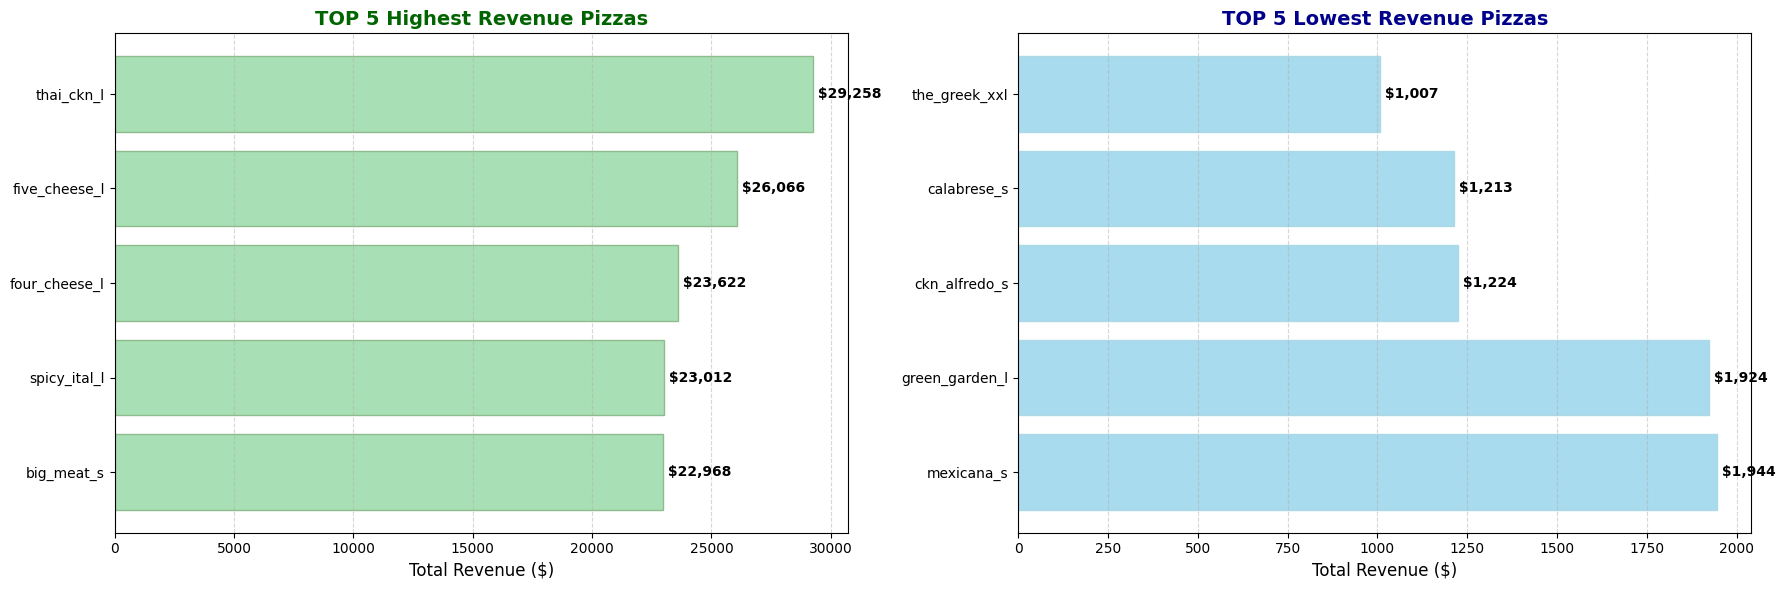

In [15]:
# 
query_top = f"""
SELECT 
    p.pizza_id,
    ROUND(SUM(od.quantity * p.price), 2) AS total_revenue
FROM `pizza-restaurant-sales.pizza_place_sales_analysis.order_details` AS od
JOIN `pizza-restaurant-sales.pizza_place_sales_analysis.pizzas` AS p
    ON od.pizza_id = p.pizza_id
GROUP BY p.pizza_id
ORDER BY total_revenue DESC
LIMIT 5
"""

# 
query_bottom = f"""
SELECT 
    p.pizza_id,
    ROUND(SUM(od.quantity * p.price), 2) AS total_revenue
FROM `pizza-restaurant-sales.pizza_place_sales_analysis.order_details` AS od
JOIN `pizza-restaurant-sales.pizza_place_sales_analysis.pizzas` AS p
    ON od.pizza_id = p.pizza_id
GROUP BY p.pizza_id
ORDER BY total_revenue ASC
LIMIT 5
"""

#
df_top_pizza_revenue = client.query(query_top).to_dataframe()
df_bottom_pizza_revenue = client.query(query_bottom).to_dataframe()

# 
df_top_pizza_revenue = df_top_pizza_revenue.sort_values(by='total_revenue', ascending=True)
df_bottom_pizza_revenue = df_bottom_pizza_revenue.sort_values(by='total_revenue', ascending=False)



fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# 1. 
ax1.barh(df_top_pizza_revenue['pizza_id'], df_top_pizza_revenue['total_revenue'], color='#a8dfb5', edgecolor='darkseagreen')
ax1.set_title('TOP 5 Highest Revenue Pizzas', fontsize=14, fontweight='bold', color='darkgreen')
ax1.set_xlabel('Total Revenue ($)', fontsize=12)
ax1.grid(axis='x', linestyle='--', alpha=0.5)


for i, val in enumerate(df_top_pizza_revenue['total_revenue']):
    ax1.text(val, i, f' ${val:,.0f}', va='center', fontsize=10, fontweight='bold')


# 2. 
ax2.barh(df_bottom_pizza_revenue['pizza_id'], df_bottom_pizza_revenue['total_revenue'], color='#a7dbed', edgecolor='lightblue')
ax2.set_title('TOP 5 Lowest Revenue Pizzas', fontsize=14, fontweight='bold', color='darkblue')
ax2.set_xlabel('Total Revenue ($)', fontsize=12)
ax2.grid(axis='x', linestyle='--', alpha=0.5)


for i, val in enumerate(df_bottom_pizza_revenue['total_revenue']):
    ax2.text(val, i, f' ${val:,.0f}', va='center', fontsize=10, fontweight='bold')



plt.tight_layout()
plt.show()

У топі найприбутковіших домінують великі розміри L, що логічно через їхню вищу вартість, крім однієї м'ясної піци маленького розміру S, яка бере високим обсягом продажів. Також бачимо, що сирні смаки (five_cheese_L — $26K; four_cheese_L — $23K) генерують колосальну частку доходу.
Розглянемо найменшприбуткові піци: Розмір XXL для грецької піци не виправдав себе — ймовірно, через високу ціну або низький попит на цей розмір.
Маленькі розміри S для калабрійської та альфредо також не приносять відчутного доходу. Рекомендую розглянути можливість вилучення з меню the_greek_XXL та заміну calabrese_S та ckn_alfredo_S — на дитячі піци (див.п.4).

 10. Зведена таблиця доходів по кожному типу піци протягом року

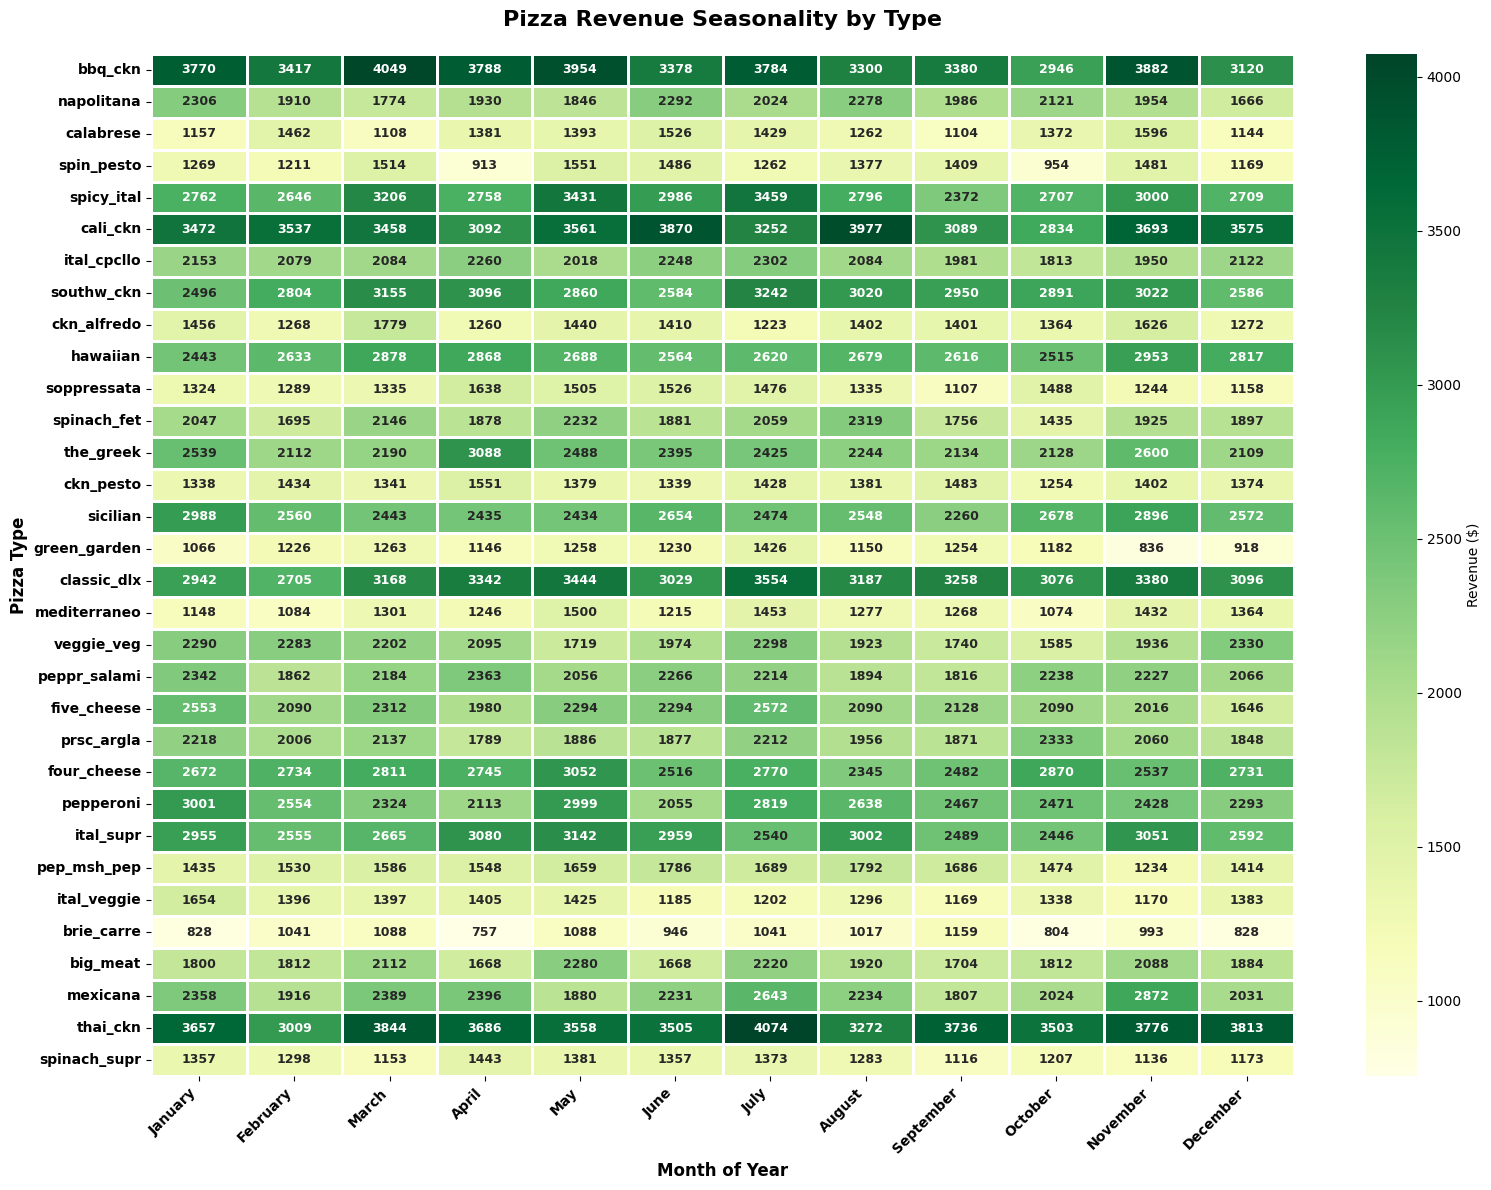

In [16]:
# 1. 
query = f"""
SELECT 
    p.pizza_type_id,
    EXTRACT(MONTH FROM o.date) AS month_num,
    FORMAT_DATE('%B', o.date) AS month_name,
    ROUND(SUM(od.quantity * p.price), 2) AS total_revenue
FROM `pizza-restaurant-sales.pizza_place_sales_analysis.order_details` AS od
JOIN `pizza-restaurant-sales.pizza_place_sales_analysis.pizzas` AS p
    ON od.pizza_id = p.pizza_id
JOIN `pizza-restaurant-sales.pizza_place_sales_analysis.orders` AS o
    ON od.order_id = o.order_id
GROUP BY p.pizza_type_id, month_num, month_name
ORDER BY p.pizza_type_id, month_num
"""

# 2. 
df_raw_seasonality = client.query(query).to_dataframe()

# 3. 
df_sorted = df_raw_seasonality.sort_values('month_num')
df_heatmap_matrix = df_sorted.pivot_table(
    index='pizza_type_id', 
    columns='month_name', 
    values='total_revenue',
    sort=False
).fillna(0)

# 4. 
plt.figure(figsize=(16, 12))

# 5. 
sns.heatmap(
    df_heatmap_matrix, 
    cmap='YlGn', 
    annot=True, 
    fmt='.0f', 
    linewidths=0.8,        
    linecolor='white',     
    annot_kws={'size': 9, 'weight': 'bold'}, 
    cbar_kws={'label': 'Revenue ($)'}
)

# 6. 
plt.title('Pizza Revenue Seasonality by Type', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Month of Year', fontsize=12, fontweight='bold')
plt.ylabel('Pizza Type', fontsize=12, fontweight='bold')

# 
plt.xticks(fontweight='bold', rotation=45, ha='right')
plt.yticks(fontweight='bold')

# 7. 
plt.tight_layout()
plt.show()

Три види піци демонструють найвищий і найстабільніший дохід протягом усього року:bbq_ckn — стабільно високі показники, пік у березні ($4К); cali_ckn — утримує лідерство майже щомісяця, з піком у червні ($3,8К); thai_ckn — демонструє рекордні продажі, особливо в липні ($4К).
Отже, піци з куркою є найпопулярнішими незалежно від сезону.
Найнижчі продажі протягом року мають brie_carre та green_garden — близько $1К на місяць. 
Рекомендую розглянути можливість вилучення з меню або заміну піци brie_carre та green_garden.
Також можна запровадити маркетингову активність на період (листопад-грудень), щоб збалансувати сезонне падіння продажів

11. Проанализуємо середній чек

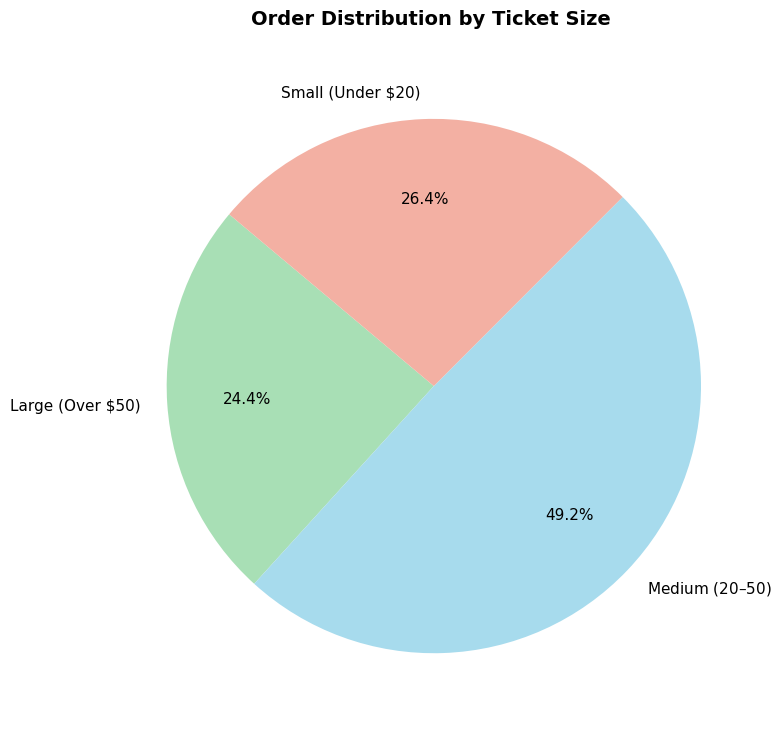

In [17]:
# 1. 
query = f"""
WITH order_revenues AS (
    SELECT 
        od.order_id,
        SUM(od.quantity * p.price) AS order_total
    FROM `pizza-restaurant-sales.pizza_place_sales_analysis.order_details` AS od
    JOIN `pizza-restaurant-sales.pizza_place_sales_analysis.pizzas` AS p
        ON od.pizza_id = p.pizza_id
    GROUP BY od.order_id
),
order_groups AS (
    SELECT 
        order_id,
        order_total,
        CASE 
            WHEN order_total < 20 THEN 'Small (Under $20)'
            WHEN order_total >= 20 AND order_total <= 50 THEN 'Medium ($20–$50)'
            ELSE 'Large (Over $50)'
        END AS ticket_size_group
    FROM order_revenues
)
SELECT 
    ticket_size_group,
    COUNT(order_id) AS total_orders,
    ROUND(COUNT(order_id) * 100.0 / SUM(COUNT(order_id)) OVER(), 1) AS percentage
FROM order_groups
GROUP BY ticket_size_group
ORDER BY ticket_size_group ASC;
"""

# 2. 
df_ticket_groups = client.query(query).to_dataframe()

# 3. 
plt.figure(figsize=(8, 8))

# 4. 
colors = ['#a8dfb5', '#a7dbed', '#f3b0a3']

# 5. 
patches, texts, autotexts = plt.pie(
    df_ticket_groups['total_orders'], 
    labels=df_ticket_groups['ticket_size_group'],   
    autopct='%1.1f%%',                             
    startangle=140,                                
    colors=colors,                                 
    pctdistance=0.7,                               
    labeldistance=1.1                              
)

# 6. 
for text in texts:
    text.set_color('black')
    text.set_fontweight('normal')
    text.set_fontsize(11)

for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontweight('normal')
    autotext.set_fontsize(11)

# 7. Д
plt.title('Order Distribution by Ticket Size ', fontsize=14, fontweight='bold', pad=20)

# 8. 
plt.tight_layout()
plt.show()

З діаграми видно, що майже половина всіх замовлень 49.2% припадає на середній сегмент $20–$50
Близько чверті усіх замовлень є великими (понад $50) - це свідчить про високу популярність групових чи сімейних замовлень.
Частка маленьких чеків (до $20) становить 26,4%.
Рекомендую запустити маркетингову активність для переведення чеків із групи Small до групи Medium, наприклад впровадити акційну пропозицію - додаткова сирна чи м'ясна начинка при замовленні мінімум на $23